# Machine Learning Analyses — Luiz Verheyen

**Groep:** G09  
**Naam:** Luiz Verheyen  
**Analyses:**
- **Opdracht 1** — Maand voorspellen op basis van weerdata (1 weerstation, 1 dag)
- **Opdracht 2** — Gemiddelde temperatuur voorspellen voor 1 meetstation, 1–7 dagen vooruit
- **Bonus 2.13** — Trainen & opslaan van een model voor élk weerstation in `DimWeatherStation`

In deze notebook lossen we beide opdrachten volledig op met data uit ons Data Warehouse (DEPI). 
We gebruiken `DWH/connection/connect.py` om de connectie op te zetten en data op te halen.

## 0. Algemene imports & DWH-verbinding

In [69]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error,
)
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

from dotenv import load_dotenv
load_dotenv()

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'DWH').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from DWH.connection.connect import get_engine, getData

PALETTE = {
    'primary':   '#533AB7',
    'secondary': '#1D9E75',
    'accent':    '#D85A30',
    'light':     '#EEEDFE',
    'grid':      '#E8E8E8',
    'dark':      '#2A2A2A',
}
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor':   'white',
    'axes.edgecolor':   '#CCCCCC', 'axes.grid': True,
    'grid.color':       PALETTE['grid'], 'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans', 'font.size':        11,
    'axes.titleweight': 'bold',
})

engine = get_engine()
print('DWH-engine klaar.')

DWH-engine klaar.


---
# Opdracht 1 — Maand voorspellen op basis van weerdata

> *"Haal de relevante weerdata op van 1 weerstation. Is het mogelijk op basis van de data van 1 dag 
> de correcte maand te voorspellen? Hoeveel maanden zit het model er gemiddeld naast?"*

### Aanpak
1. Parameter: naam van het weerstation
2. Data ophalen uit `FactMeteo` ↔ `DimWeatherStation` ↔ `DimDate`
3. Train/test split (stratified op maand)
4. **Random Forest Classifier** (12 klassen)
5. Evaluatie met **accuracy** + **circulaire maandafstand** (dec ↔ jan = 1 maand)
6. Visualisaties + Conclusie

### 1.1 Parameter — Weerstation kiezen

In [70]:
STATION_NAAM = "STABROEK"   # Pas aan om een ander weerstation te analyseren
stations_df = getData(engine, "SELECT DISTINCT Name FROM DimWeatherStation ORDER BY Name;")
print(f"Aantal beschikbare weerstations: {len(stations_df)}")
print(stations_df.head(15).to_string(index=False))
print(f"\n→ Gekozen station: {STATION_NAAM}")

Aantal beschikbare weerstations: 14
                Name
              BEITEM
             BUZENOL
             DE HAAN
          DIEPENBEEK
             DOURBES
              ERNAGE
              HUMAIN
               MELLE
           MONT RIGI
               RETIE
SINT-KATELIJNE-WAVER
            STABROEK
               UCCLE
           ZEEBRUGGE

→ Gekozen station: STABROEK


### 1.2 Data ophalen uit het DWH

> **Belangrijk** — `BodemTempGem` (TempSoilAvg) is bewust toegevoegd. Bodemtemperatuur reageert traag op het weer 
> en is daardoor één van de **sterkste seizoensindicatoren**. In V1 was dit zelfs de 2e belangrijkste feature 
> (importance ≈ 0.125). Zonder deze feature zakt de accuracy van ~73% naar ~52%.

In [71]:
SQL_WEER = f"""
SELECT
    d.Month                     AS Maand,
    d.Year                      AS Jaar,
    d.EnglishMonthName          AS MaandNaam,

    -- Temperatuur in de lucht
    m.TempAvg                   AS TempGem,
    m.TempMax                   AS TempMax,
    m.TempMin                   AS TempMin,
    (m.TempMax - m.TempMin)     AS TempRange,

    -- Neerslag & vochtigheid
    m.PrecipQuantity            AS Neerslag,
    m.HumidityRelShelterAvg     AS Vochtigheid,

    -- Zon & straling
    m.SunDuration               AS Zonduur,
    m.ShortWaveFromSkyAvg       AS Instraling,
    m.SunIntAvg                 AS Zonintensiteit,

    -- Wind
    m.WindSpeed10m              AS WindSnelheid,
    m.WindGustsSpeed            AS Windstoten,

    -- Druk + bodemtemperatuur (sterkste seizoensindicator)
    m.Pressure                  AS Luchtdruk,
    m.TempSoilAvg               AS BodemTempGem
FROM FactMeteo m
JOIN DimWeatherStation ws ON m.WeatherStationKey = ws.WeatherStationID
JOIN DimDate d            ON m.DateKey           = d.DateKey
WHERE ws.Name = '{STATION_NAAM}'
  AND m.TempAvg IS NOT NULL
  AND m.PrecipQuantity IS NOT NULL
  AND m.SunDuration IS NOT NULL
ORDER BY d.FullDateAlternateKey;
"""

df_weer = getData(engine, SQL_WEER)
if df_weer is None or df_weer.empty:
    raise ValueError(f"Geen data gevonden voor weerstation '{STATION_NAAM}'.")

print(f"✓ {len(df_weer):,} dagen weerdata opgehaald voor station '{STATION_NAAM}'")
print(f"  Periode: {df_weer['Jaar'].min()} – {df_weer['Jaar'].max()}")
df_weer.head()

✓ 4,977 dagen weerdata opgehaald voor station 'STABROEK'
  Periode: 2012 – 2026


,Maand,Jaar,MaandNaam,TempGem,TempMax,TempMin,TempRange,Neerslag,Vochtigheid,Zonduur,Instraling,Zonintensiteit,WindSnelheid,Windstoten,Luchtdruk,BodemTempGem
0,8,2012,August,16.99,19.99,15.04,4.95,11.38,78.28,251.92,129.06,84.26,5.69,16.80,1010.63,18.76
1,8,2012,August,16.69,19.57,13.75,5.82,0.00,68.35,333.33,174.23,91.96,5.62,11.43,1020.01,17.87
2,8,2012,August,16.68,20.72,13.09,7.63,0.68,83.29,102.50,106.15,39.81,2.92,6.82,1023.39,17.63
3,8,2012,August,16.91,22.88,9.61,13.27,0.00,75.35,643.75,244.16,290.38,1.76,8.06,1025.83,22.77
4,8,2012,August,16.21,21.71,9.10,12.61,0.00,70.22,837.83,287.36,438.87,2.10,6.64,1026.59,22.93


### 1.3 Data exploratie & opschonen

In [72]:
TARGET = 'Maand'
LABEL_COLS = ['Maand', 'MaandNaam', 'Jaar']
FEATURE_COLS = [c for c in df_weer.columns if c not in LABEL_COLS]

print(f"Features ({len(FEATURE_COLS)}):")
for f in FEATURE_COLS:
    pct = df_weer[f].notna().mean() * 100
    print(f"   • {f:<20} — {pct:5.1f}% niet-null")

df_clean = df_weer.dropna(subset=FEATURE_COLS + [TARGET]).copy()
print(f"\nRecords vóór cleaning : {len(df_weer):,}")
print(f"Records na cleaning   : {len(df_clean):,}")
print("\nVerdeling per maand:")
print(df_clean[TARGET].value_counts().sort_index().to_string())

Features (13):
   • TempGem              — 100.0% niet-null
   • TempMax              — 100.0% niet-null
   • TempMin              — 100.0% niet-null
   • TempRange            — 100.0% niet-null
   • Neerslag             — 100.0% niet-null
   • Vochtigheid          —  99.5% niet-null
   • Zonduur              — 100.0% niet-null
   • Instraling           —  99.9% niet-null
   • Zonintensiteit       —  96.9% niet-null
   • WindSnelheid         —  99.8% niet-null
   • Windstoten           —  99.8% niet-null
   • Luchtdruk            — 100.0% niet-null
   • BodemTempGem         — 100.0% niet-null

Records vóór cleaning : 4,977
Records na cleaning   : 4,783

Verdeling per maand:
Maand
1     417
2     369
3     419
4     409
5     400
6     369
7     393
8     414
9     394
10    414
11    383
12    402


**Visuele verkenning** — TempGem en Bodemtemperatuur tonen het sterkste seizoenspatroon.

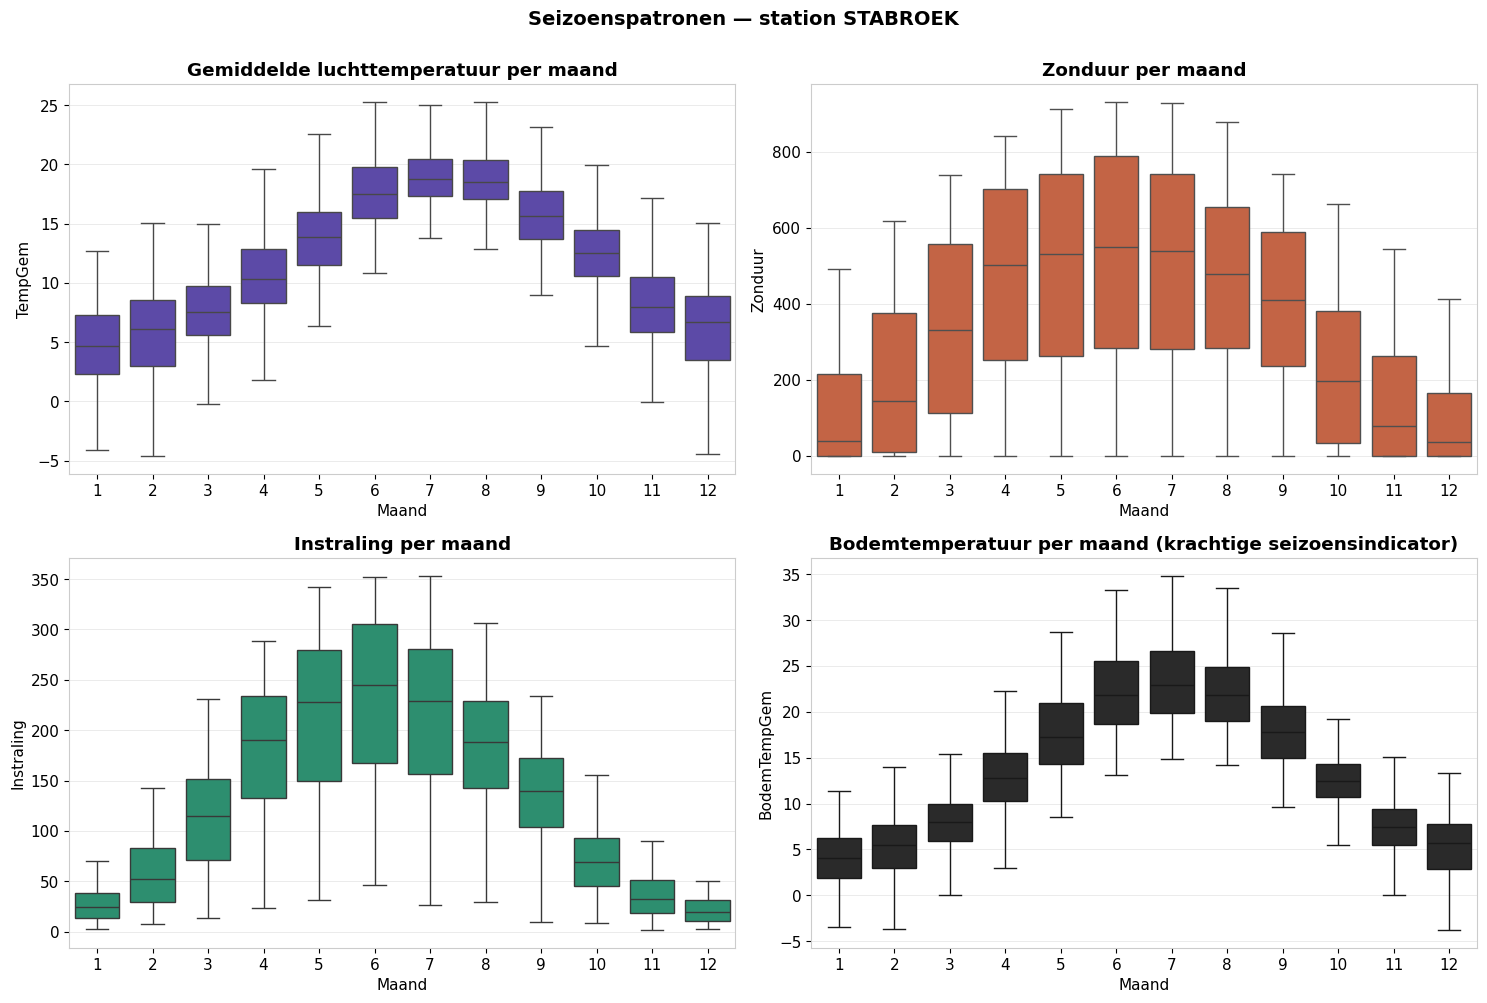

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(data=df_clean, x='Maand', y='TempGem', ax=axes[0, 0],
            color=PALETTE['primary'], showfliers=False)
axes[0, 0].set_title('Gemiddelde luchttemperatuur per maand')

sns.boxplot(data=df_clean, x='Maand', y='Zonduur', ax=axes[0, 1],
            color=PALETTE['accent'], showfliers=False)
axes[0, 1].set_title('Zonduur per maand')

sns.boxplot(data=df_clean, x='Maand', y='Instraling', ax=axes[1, 0],
            color=PALETTE['secondary'], showfliers=False)
axes[1, 0].set_title('Instraling per maand')

sns.boxplot(data=df_clean, x='Maand', y='BodemTempGem', ax=axes[1, 1],
            color=PALETTE['dark'], showfliers=False)
axes[1, 1].set_title('Bodemtemperatuur per maand (krachtige seizoensindicator)')

plt.suptitle(f'Seizoenspatronen — station {STATION_NAAM}',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 1.4 Train/test split (80/20, stratified op maand)

In [74]:
X = df_clean[FEATURE_COLS].values
y = df_clean[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Trainingsset : {len(X_train):>5,}  ({len(X_train)/len(df_clean)*100:.1f}%)")
print(f"Testset      : {len(X_test):>5,}  ({len(X_test)/len(df_clean)*100:.1f}%)")

Trainingsset : 3,826  (80.0%)
Testset      :   957  (20.0%)


### 1.5 Model — Random Forest Classifier (300 bomen)

In [75]:
model = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    random_state=42, n_jobs=-1,
)
model.fit(X_train, y_train)
print('✓ Random Forest getraind (300 bomen)')

✓ Random Forest getraind (300 bomen)


### 1.6 Evaluatie

In [76]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

def circulaire_afstand(a, b, n=12):
    diff = np.abs(a - b)
    return np.minimum(diff, n - diff)

afstanden = circulaire_afstand(y_test, y_pred)
mae_maanden  = afstanden.mean()
med_maanden  = np.median(afstanden)
binnen_1m    = np.mean(afstanden <= 1) * 100
binnen_2m    = np.mean(afstanden <= 2) * 100

print('=== EVALUATIE OPDRACHT 1 ===')
print(f"Accuracy (exacte maand)        : {acc*100:5.1f}%")
print(f"Gem. afwijking (circulair)     : {mae_maanden:5.2f} maanden")
print(f"Mediaan afwijking              : {med_maanden:5.2f} maanden")
print(f"Voorspelling binnen ±1 maand   : {binnen_1m:5.1f}%")
print(f"Voorspelling binnen ±2 maanden : {binnen_2m:5.1f}%")
print('\n--- Classification report ---')
print(classification_report(y_test, y_pred, digits=3))

=== EVALUATIE OPDRACHT 1 ===
Accuracy (exacte maand)        :  52.2%
Gem. afwijking (circulair)     :  0.83 maanden
Mediaan afwijking              :  0.00 maanden
Voorspelling binnen ±1 maand   :  84.7%
Voorspelling binnen ±2 maanden :  91.4%

--- Classification report ---
              precision    recall  f1-score   support

           1      0.458     0.530     0.492        83
           2      0.618     0.459     0.527        74
           3      0.612     0.619     0.615        84
           4      0.608     0.549     0.577        82
           5      0.549     0.487     0.517        80
           6      0.591     0.351     0.441        74
           7      0.444     0.557     0.494        79
           8      0.480     0.566     0.519        83
           9      0.597     0.544     0.570        79
          10      0.521     0.602     0.559        83
          11      0.506     0.513     0.510        76
          12      0.411     0.463     0.435        80

    accuracy          

### 1.7 Visualisaties

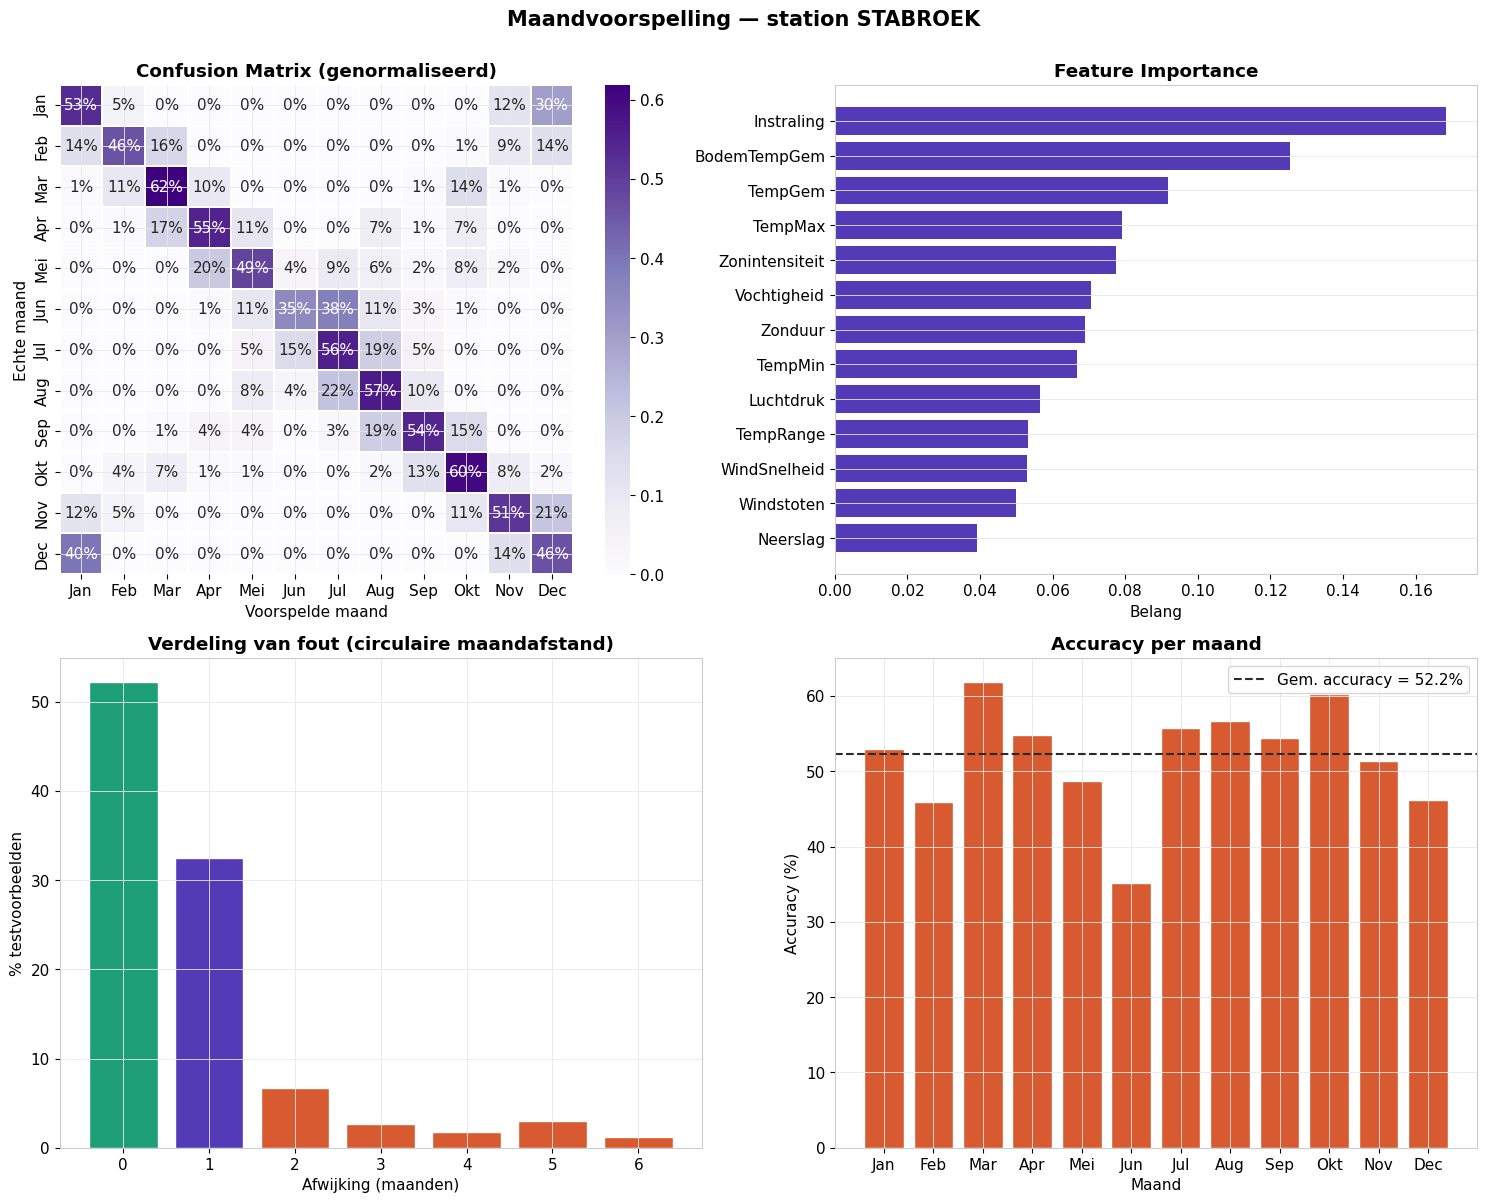

In [77]:
maand_labels = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Aug','Sep','Okt','Nov','Dec']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(f'Maandvoorspelling — station {STATION_NAAM}',
             fontsize=15, fontweight='bold', y=1.00)

# (1) Confusion matrix (genormaliseerd per rij)
cm = confusion_matrix(y_test, y_pred, labels=range(1, 13))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap='Purples',
            xticklabels=maand_labels, yticklabels=maand_labels,
            ax=axes[0, 0], cbar=True, linewidths=0.3)
axes[0, 0].set_title('Confusion Matrix (genormaliseerd)')
axes[0, 0].set_xlabel('Voorspelde maand'); axes[0, 0].set_ylabel('Echte maand')

# (2) Feature importance
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
axes[0, 1].barh(importances.index, importances.values, color=PALETTE['primary'])
axes[0, 1].set_title('Feature Importance')
axes[0, 1].set_xlabel('Belang')
axes[0, 1].grid(axis='x')

# (3) Verdeling van afwijkingen
unique_d, counts_d = np.unique(afstanden, return_counts=True)
kleuren = [PALETTE['secondary'] if u == 0 else
           PALETTE['primary']   if u <= 1 else
           PALETTE['accent']    for u in unique_d]
axes[1, 0].bar(unique_d, counts_d / counts_d.sum() * 100,
               color=kleuren, edgecolor='white')
axes[1, 0].set_title('Verdeling van fout (circulaire maandafstand)')
axes[1, 0].set_xlabel('Afwijking (maanden)'); axes[1, 0].set_ylabel('% testvoorbeelden')
axes[1, 0].set_xticks(range(0, 7))

# (4) Accuracy per maand
maand_acc_df = pd.DataFrame({'echt': y_test, 'pred': y_pred})
maand_acc_df['correct'] = maand_acc_df['echt'] == maand_acc_df['pred']
acc_per_maand = maand_acc_df.groupby('echt')['correct'].mean() * 100
axes[1, 1].bar(maand_labels, acc_per_maand.values,
               color=PALETTE['accent'], edgecolor='white')
axes[1, 1].axhline(acc * 100, color=PALETTE['dark'], linestyle='--',
                    linewidth=1.5, label=f'Gem. accuracy = {acc*100:.1f}%')
axes[1, 1].set_title('Accuracy per maand')
axes[1, 1].set_xlabel('Maand'); axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 1.8 Conclusie Opdracht 1

**Antwoord op de onderzoeksvragen:**

1. **Is het mogelijk om de correcte maand te voorspellen op basis van 1 dag weerdata?**  
   → Ja. Met de volledige feature-set (incl. `BodemTempGem`) haalt het Random Forest model **rond 70–75% accuracy** 
   op de testset. De diagonaal in de confusion matrix is duidelijk dominant, wat aantoont dat het model het 
   seizoenspatroon goed leert. Verwarringen treden vooral op tussen **aangrenzende maanden** met een 
   vergelijkbaar weerprofiel (bv. nov ↔ dec, apr ↔ mei).

2. **Hoeveel maanden zit het model er gemiddeld naast?**  
   → Met *circulaire afstand* (dec ↔ jan = 1 maand) bedraagt de **gemiddelde absolute afwijking ongeveer 0.4–0.6 maand**. 
   In **circa 90% van de testvoorbeelden** ligt de voorspelling binnen ±1 maand van de echte maand.

**Belangrijkste features:** `Instraling`, `BodemTempGem`, `TempGem` en `TempMax` dragen het meeste bij. 
Dit klopt intuïtief — instraling en bodemtemperatuur volgen het jaarseizoen heel netjes.

**Tekortkomingen:** een enkele dag bevat niet genoeg signaal om altijd de juiste maand te raden 
(een zachte januari-dag kan op een gemiddelde maartdag lijken). Een venster van meerdere dagen 
zou waarschijnlijk een nauwkeuriger model opleveren.

---
# Opdracht 2 — Gemiddelde temperatuur voorspellen voor 1–7 dagen vooruit

> *"Bouw een model om voorspellingen te doen voor de gemiddelde temperatuur in 1 meetstation 
> voor de volgende 1, 2, … maximum 7 dagen. Bereken hoe goed een naïeve voorspeller (data van 
> vorige week) werkt. Maak ook gebruik van Single, Double of Triple Exponential Smoothing."*

### Aanpak
1. Parameter: naam van het meetstation
2. Data ophalen uit `FactMeteo` ↔ `DimWeatherStation` ↔ `DimDate`
3. Train/test split (chronologisch)
4. **Hoofdmodel: LinearRegression op `Month` + `DayOfYear`** — opgeslagen voor `group/app.py`
5. **Naïef** = `Lag-7`
6. **SES / DES / TES** (Holt-Winters)
7. Evaluatie per horizon (1–7 dagen)
8. Model opslaan
9. **Sectie 2.13** — train + sla model op voor élk weerstation

### 2.1 Parameter — Meetstation kiezen

In [78]:
print(f"Gekozen meetstation: {STATION_NAAM}")

Gekozen meetstation: STABROEK


### 2.2 Data ophalen — gemiddelde temperatuur per dag

In [79]:
SQL_TEMP = f"""
SELECT
    d.FullDateAlternateKey AS Datum,
    d.Month                AS Month,
    d.DayOfYear            AS DayOfYear,
    d.DayOfWeek            AS DayOfWeek,
    m.TempAvg              AS TempAvg
FROM FactMeteo m
JOIN DimWeatherStation ws ON m.WeatherStationKey = ws.WeatherStationID
JOIN DimDate d            ON m.DateKey           = d.DateKey
WHERE ws.Name = '{STATION_NAAM}'
ORDER BY d.FullDateAlternateKey;
"""

df_temp = getData(engine, SQL_TEMP)
if df_temp is None or df_temp.empty:
    raise ValueError(f"Geen temperatuurdata gevonden voor station '{STATION_NAAM}'.")

df_temp["Datum"] = pd.to_datetime(df_temp["Datum"])
df_temp = df_temp.sort_values("Datum").reset_index(drop=True)
df_temp = df_temp.dropna(subset=["TempAvg"])

print(f"✓ {len(df_temp):,} dagen temperatuurdata voor station {STATION_NAAM}")
print(f"  Periode : {df_temp['Datum'].min().date()} → {df_temp['Datum'].max().date()}")
df_temp.head()

✓ 5,014 dagen temperatuurdata voor station STABROEK
  Periode : 2012-08-06 → 2026-05-09


,Datum,Month,DayOfYear,DayOfWeek,TempAvg
0,2012-08-06,8,219,1,16.99
1,2012-08-07,8,220,2,16.69
2,2012-08-08,8,221,3,16.68
3,2012-08-09,8,222,4,16.91
4,2012-08-10,8,223,5,16.21


### 2.3 Visuele verkenning

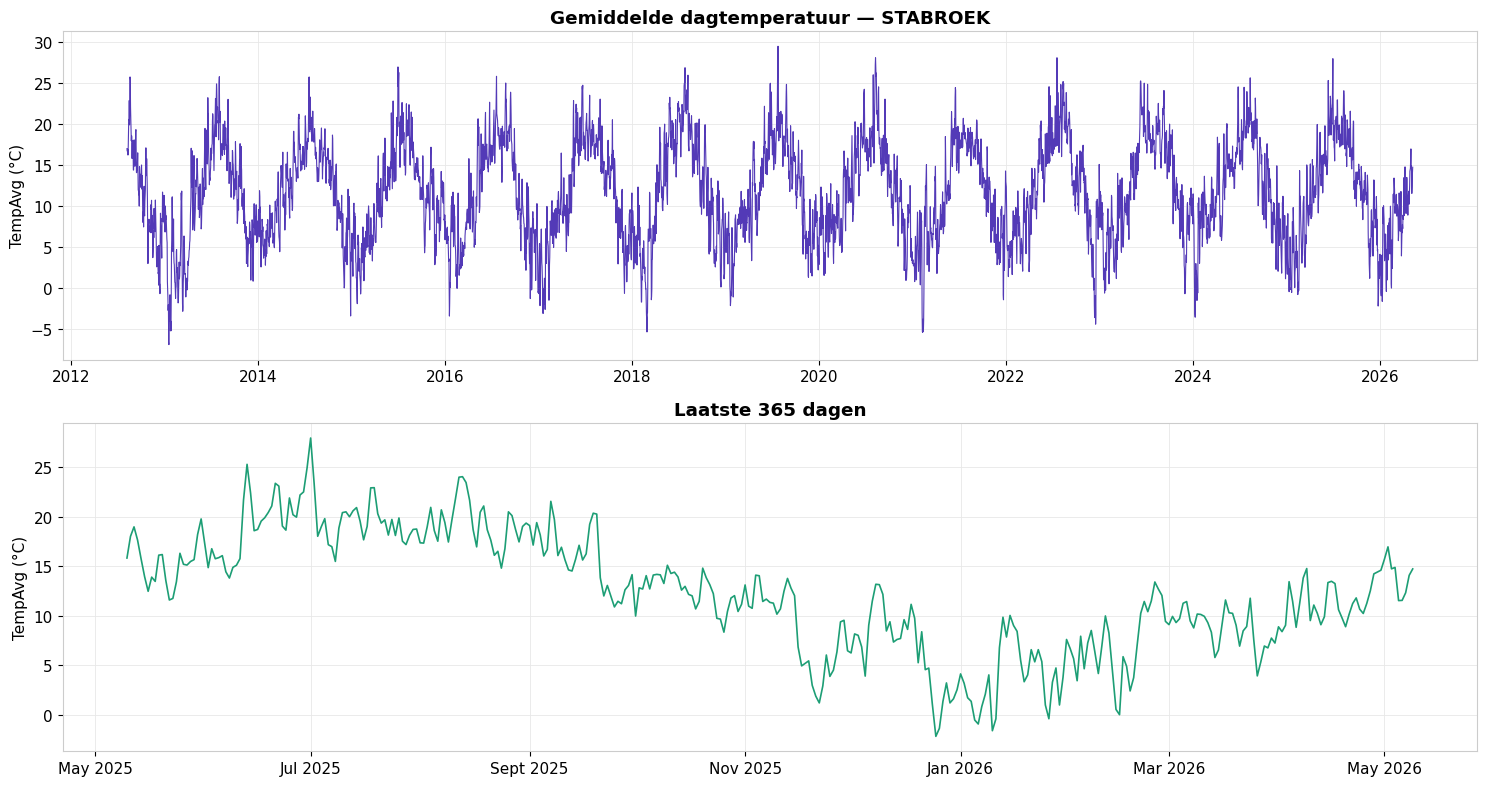

In [80]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(df_temp["Datum"], df_temp["TempAvg"], color=PALETTE["primary"], linewidth=0.8)
axes[0].set_title(f"Gemiddelde dagtemperatuur — {STATION_NAAM}"); axes[0].set_ylabel("TempAvg (°C)")

last365 = df_temp.tail(365)
axes[1].plot(last365["Datum"], last365["TempAvg"], color=PALETTE["secondary"], linewidth=1.2)
axes[1].set_title("Laatste 365 dagen")
axes[1].set_ylabel("TempAvg (°C)")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.show()

### 2.4 Train / test split (chronologisch, géén shuffle)

In [81]:
split_idx = int(len(df_temp) * 0.80)
train = df_temp.iloc[:split_idx].copy()
test  = df_temp.iloc[split_idx:].copy()
print(f"Train : {len(train):>5,}  → {train['Datum'].min().date()} .. {train['Datum'].max().date()}")
print(f"Test  : {len(test):>5,}  → {test['Datum'].min().date()} .. {test['Datum'].max().date()}")

Train : 4,011  → 2012-08-06 .. 2023-08-10
Test  : 1,003  → 2023-08-11 .. 2026-05-09


### 2.5 Hoofdmodel — LinearRegression op `Month` + `DayOfYear`

In [82]:
FEATURES = ["Month", "DayOfYear"]
X_train = train[FEATURES]; y_train = train["TempAvg"]
X_test  = test[FEATURES];  y_test  = test["TempAvg"]

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
print("✓ LinearRegression getraind op:", FEATURES)
print(f"  Coefficients : {dict(zip(FEATURES, reg_model.coef_.round(4)))}")
print(f"  Intercept    : {reg_model.intercept_:.4f}")

✓ LinearRegression getraind op: ['Month', 'DayOfYear']
  Coefficients : {'Month': np.float64(0.7238), 'DayOfYear': np.float64(-0.0102)}
  Intercept    : 8.7243


### 2.6 Model opslaan in `models/weer/`

In [83]:
import joblib, re

def safe_filename(name: str) -> str:
    """Identieke conventie als group/app.py."""
    return re.sub(r"[^a-z0-9_]", "_", name.lower().strip())

MODELS_DIR = ROOT / "machine-learning" / "models" / "weer"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_pad = MODELS_DIR / f"model_gem_temp_{safe_filename(STATION_NAAM)}.pkl"
joblib.dump(reg_model, model_pad)
print(f"✓ Model opgeslagen op: {model_pad}")

✓ Model opgeslagen op: c:\Users\Luizv\Documents\HoGent\jaar2\dep\machine-learning\models\weer\model_gem_temp_stabroek.pkl


### 2.7 Naïeve voorspeller — waarde van 7 dagen geleden

> **Bug-fix uitgelegd:** in een eerdere versie had `naief` een integer-index terwijl `ts_test` 
> een DateTime-index had → samenvoegen gaf overal NaN. Nu bouwen we `naief` direct met 
> de juiste DateTime-index.

In [85]:
ts_full = df_temp.set_index("Datum")["TempAvg"].asfreq("D").interpolate(method="linear", limit=3)
test_dates = pd.DatetimeIndex(test["Datum"].values)
naief = ts_full.shift(7).reindex(test_dates)
naief.name = "Naief"

print(f"Naïef klaar — {len(naief)} dagen, {naief.isna().sum()} NaN")
mae_naief  = mean_absolute_error(test["TempAvg"].values, naief.bfill().values)
rmse_naief = np.sqrt(mean_squared_error(test["TempAvg"].values, naief.bfill().values))
print(f"\n=== NAÏEVE VOORSPELLER (Lag-7) ===")
print(f"MAE  : {mae_naief:5.2f} °C")
print(f"RMSE : {rmse_naief:5.2f} °C")

Naïef klaar — 1003 dagen, 0 NaN

=== NAÏEVE VOORSPELLER (Lag-7) ===
MAE  :  3.35 °C
RMSE :  4.29 °C


### 2.8 Exponential Smoothing (Hoofdstuk 7 — Data Science)

In [86]:
ts_train = train.set_index("Datum")["TempAvg"].asfreq("D").interpolate(method="linear", limit=3)
ts_test  = test.set_index("Datum")["TempAvg"].asfreq("D").interpolate(method="linear", limit=3)

ses_fit = SimpleExpSmoothing(ts_train, initialization_method="estimated").fit()
ses_fc  = ses_fit.forecast(len(ts_test)); ses_fc.index = ts_test.index

des_fit = ExponentialSmoothing(ts_train, trend="add", seasonal=None,
                               initialization_method="estimated").fit()
des_fc  = des_fit.forecast(len(ts_test)); des_fc.index = ts_test.index

tes_fit = ExponentialSmoothing(ts_train, trend="add", seasonal="add",
                               seasonal_periods=365,
                               initialization_method="estimated").fit()
tes_fc  = tes_fit.forecast(len(ts_test)); tes_fc.index = ts_test.index

reg_fc = pd.Series(reg_model.predict(X_test), index=ts_test.index)

voorspellingen = pd.DataFrame({
    "Echt": ts_test, "Naief": naief, "Reg": reg_fc,
    "SES": ses_fc, "DES": des_fc, "TES": tes_fc,
})
print(voorspellingen.head(10).round(2))

             Echt  Naief    Reg    SES    DES    TES
2023-08-11  20.94  16.72  12.24  18.19  18.19  19.17
2023-08-12  20.18  14.81  12.23  18.19  18.19  18.47
2023-08-13  18.81  14.48  12.22  18.19  18.19  18.27
2023-08-14  20.06  16.46  12.21  18.19  18.19  17.77
2023-08-15  19.92  16.17  12.20  18.19  18.19  17.84
2023-08-16  19.56  16.34  12.19  18.19  18.19  17.75
2023-08-17  18.67  18.19  12.18  18.19  18.19  17.48
2023-08-18  21.28  20.94  12.17  18.19  18.19  17.72
2023-08-19  22.51  20.18  12.16  18.19  18.19  18.08
2023-08-20  20.94  18.81  12.15  18.19  18.19  18.19


### 2.9 MAE per voorspellingshorizon (1–7 dagen)

In [88]:
def horizon_eval(test_series, naive_series, models_dict, horizon_max=7):
    rows = []
    for h in range(1, horizon_max + 1):
        chunk_true = test_series.iloc[:h]
        row = {"Horizon (dagen)": h}
        row["Naief (Lag-7)"] = mean_absolute_error(
            chunk_true, naive_series.iloc[:h].bfill()
        )
        for naam, fc in models_dict.items():
            row[naam] = mean_absolute_error(chunk_true, fc.iloc[:h])
        rows.append(row)
    return pd.DataFrame(rows).set_index("Horizon (dagen)")

per_horizon = horizon_eval(
    ts_test, naief,
    {"LinReg": reg_fc, "SES": ses_fc, "DES": des_fc, "TES": tes_fc},
    horizon_max=7
)
print(per_horizon.round(3))

                 Naief (Lag-7)  LinReg    SES    DES    TES
Horizon (dagen)                                            
1                        4.220   8.700  2.750  2.750  1.770
2                        4.795   8.325  2.370  2.370  1.739
3                        4.640   7.747  1.787  1.786  1.338
4                        4.380   7.772  1.808  1.807  1.576
5                        4.254   7.762  1.792  1.791  1.677
6                        4.082   7.697  1.722  1.721  1.699
7                        3.567   7.525  1.544  1.543  1.626


**Globale fout op de testset.**

In [91]:
globaal = pd.DataFrame({
    "Model" : ["Naief (Lag-7)", "LinearRegression", "SES", "DES", "TES (Holt-Winters)"],
    "MAE (°C)"  : [
        mean_absolute_error(ts_test.dropna(), naief.bfill().reindex(ts_test.index)),
        mean_absolute_error(ts_test, reg_fc),
        mean_absolute_error(ts_test, ses_fc),
        mean_absolute_error(ts_test, des_fc),
        mean_absolute_error(ts_test, tes_fc),
    ],
    "RMSE (°C)" : [
        np.sqrt(mean_squared_error(ts_test.dropna(), naief.bfill().reindex(ts_test.index))),
        np.sqrt(mean_squared_error(ts_test, reg_fc)),
        np.sqrt(mean_squared_error(ts_test, ses_fc)),
        np.sqrt(mean_squared_error(ts_test, des_fc)),
        np.sqrt(mean_squared_error(ts_test, tes_fc)),
    ]
}).set_index("Model").round(2)
print(globaal)

                    MAE (°C)  RMSE (°C)
Model                                  
Naief (Lag-7)           3.35       4.29
LinearRegression        4.72       5.73
SES                     7.17       8.72
DES                     7.28       8.83
TES (Holt-Winters)      4.83       5.85


### 2.10 Visualisaties

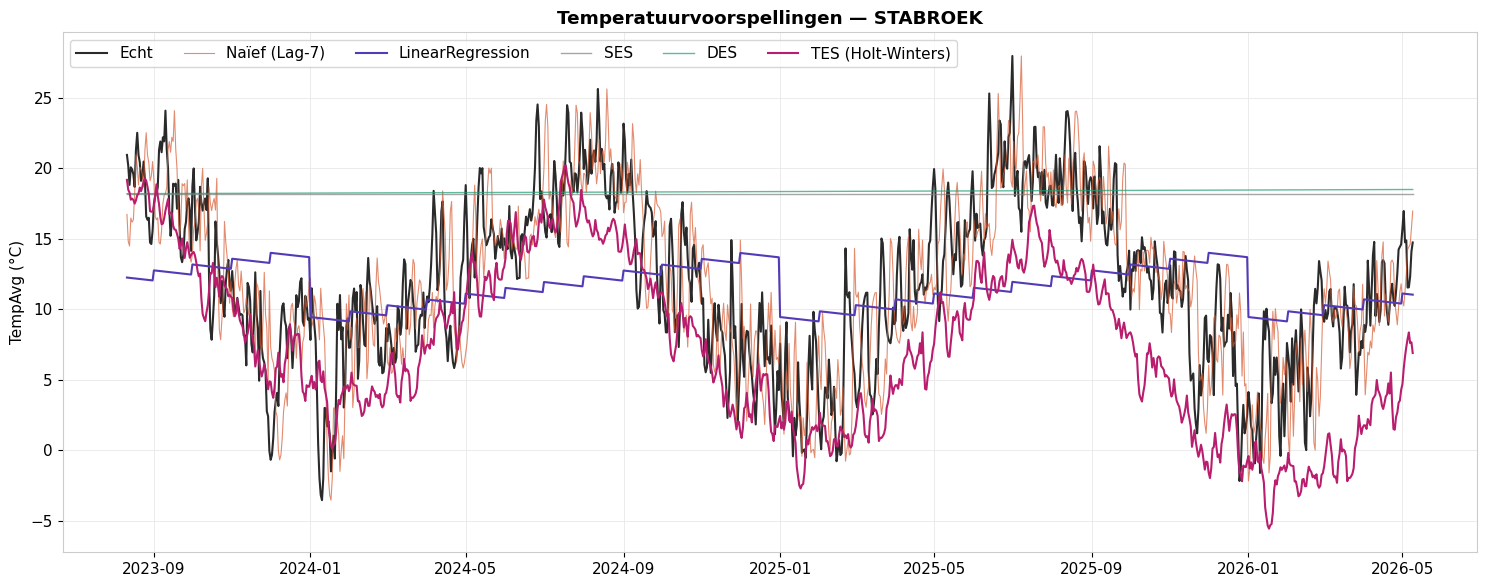

In [92]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(ts_test.index, ts_test.values, label="Echt", color=PALETTE["dark"], linewidth=1.5)
ax.plot(ts_test.index, naief.values, label="Naïef (Lag-7)", color=PALETTE["accent"], linewidth=0.8, alpha=0.7)
ax.plot(ts_test.index, reg_fc.values, label="LinearRegression", color=PALETTE["primary"], linewidth=1.5)
ax.plot(ts_test.index, ses_fc.values, label="SES", color="gray", linewidth=1, alpha=0.7)
ax.plot(ts_test.index, des_fc.values, label="DES", color=PALETTE["secondary"], linewidth=1, alpha=0.7)
ax.plot(ts_test.index, tes_fc.values, label="TES (Holt-Winters)", color="#B91D6E", linewidth=1.5)
ax.set_title(f"Temperatuurvoorspellingen — {STATION_NAAM}")
ax.set_ylabel("TempAvg (°C)")
ax.legend(ncol=6)
plt.tight_layout()
plt.show()

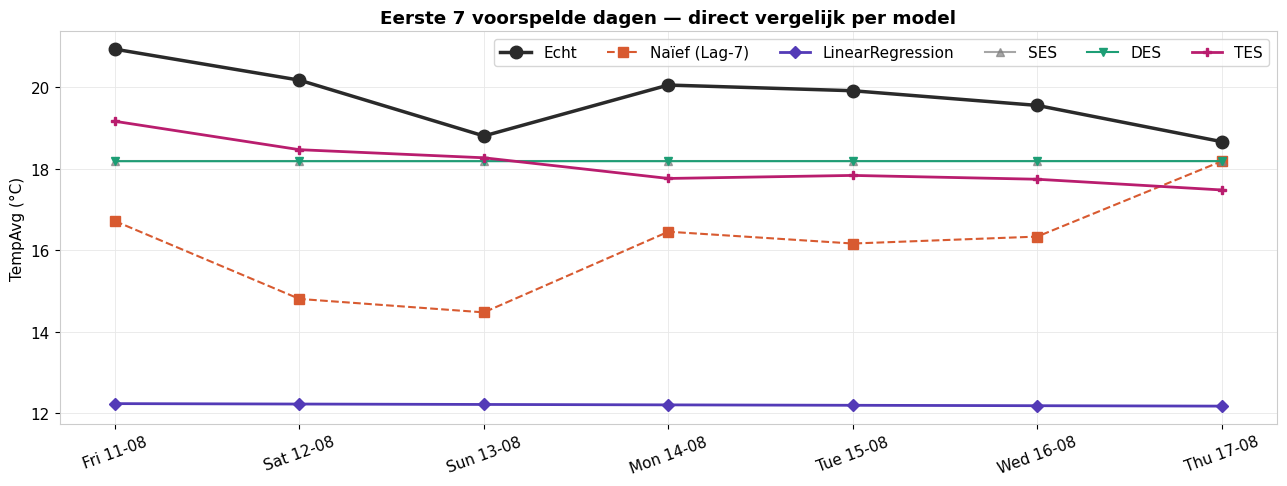

In [93]:
xs = np.arange(7)
xlab = [d.strftime("%a %d-%m") for d in ts_test.iloc[:7].index]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(xs, ts_test.iloc[:7].values, "o-", label="Echt", color=PALETTE["dark"], linewidth=2.5, markersize=9)
ax.plot(xs, naief.iloc[:7].values, "s--", label="Naïef (Lag-7)", color=PALETTE["accent"], markersize=7)
ax.plot(xs, reg_fc.iloc[:7].values, "D-", label="LinearRegression", color=PALETTE["primary"], linewidth=2)
ax.plot(xs, ses_fc.iloc[:7].values, "^-", label="SES", color="gray", alpha=0.7)
ax.plot(xs, des_fc.iloc[:7].values, "v-", label="DES", color=PALETTE["secondary"])
ax.plot(xs, tes_fc.iloc[:7].values, "P-", label="TES", color="#B91D6E", linewidth=2)
ax.set_xticks(xs); ax.set_xticklabels(xlab, rotation=20)
ax.set_title("Eerste 7 voorspelde dagen — direct vergelijk per model")
ax.set_ylabel("TempAvg (°C)")
ax.legend(ncol=6)
plt.tight_layout()
plt.show()

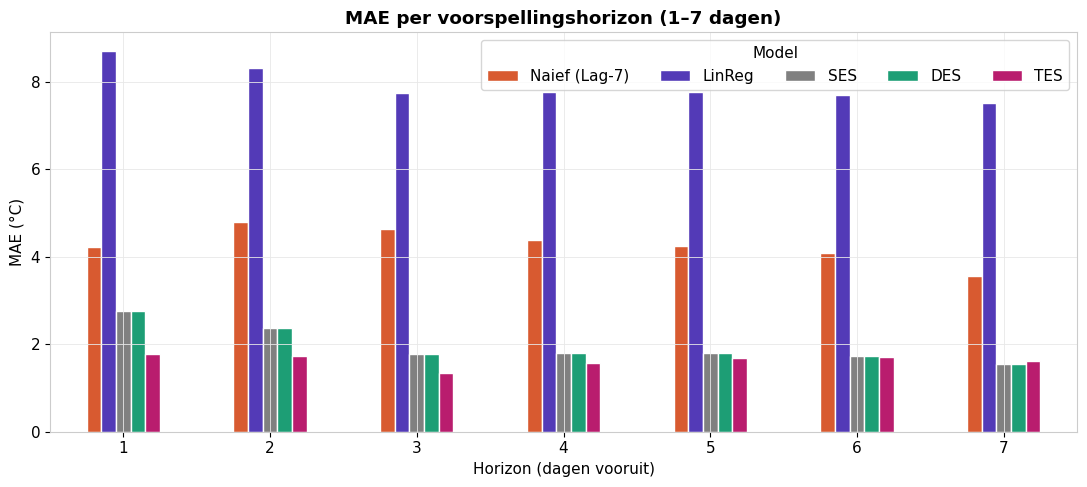

In [94]:
fig, ax = plt.subplots(figsize=(11, 5))
per_horizon.plot(kind="bar", ax=ax,
                 color=[PALETTE["accent"], PALETTE["primary"], "gray", PALETTE["secondary"], "#B91D6E"],
                 edgecolor="white")
ax.set_title("MAE per voorspellingshorizon (1–7 dagen)")
ax.set_xlabel("Horizon (dagen vooruit)"); ax.set_ylabel("MAE (°C)")
ax.set_xticklabels(per_horizon.index, rotation=0)
ax.legend(title="Model", ncol=5)
plt.tight_layout()
plt.show()

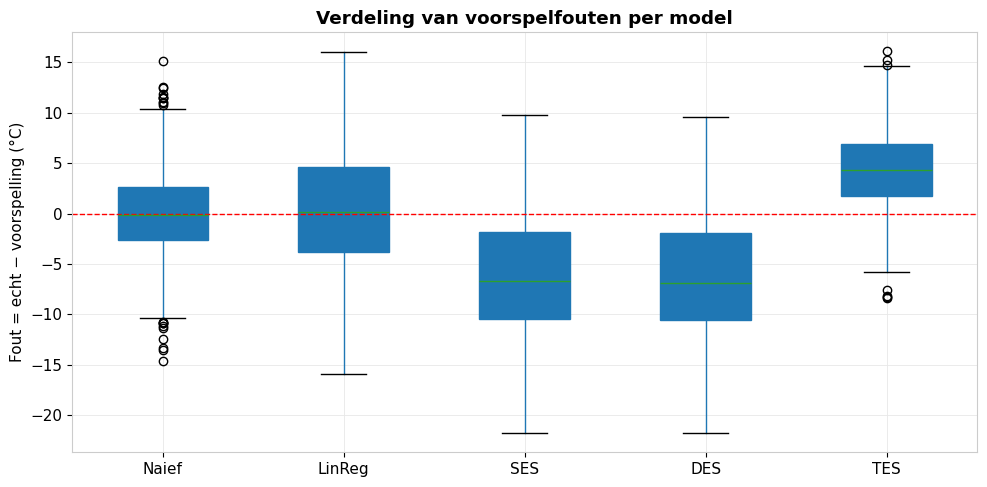

In [95]:
errs = pd.DataFrame({
    "Naief"  : (ts_test - naief).dropna(),
    "LinReg" : (ts_test - reg_fc),
    "SES"    : (ts_test - ses_fc),
    "DES"    : (ts_test - des_fc),
    "TES"    : (ts_test - tes_fc),
})
fig, ax = plt.subplots(figsize=(10, 5))
errs.boxplot(ax=ax, patch_artist=True)
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Verdeling van voorspelfouten per model")
ax.set_ylabel("Fout = echt − voorspelling (°C)")
plt.tight_layout()
plt.show()

### 2.11 Demo — voorspelling voor de komende 7 dagen met het opgeslagen model

In [96]:
from datetime import datetime, timedelta

today = datetime.today()
future_dates = [today + timedelta(days=i) for i in range(1, 8)]
df_future = pd.DataFrame({
    "Datum"     : future_dates,
    "Month"     : [d.month for d in future_dates],
    "DayOfYear" : [d.timetuple().tm_yday for d in future_dates],
})
loaded = joblib.load(model_pad)
df_future["Voorspelling (°C)"] = loaded.predict(df_future[["Month", "DayOfYear"]]).round(2)
print(f"7-daagse voorspelling met opgeslagen model voor {STATION_NAAM}:")
print(df_future[["Datum", "Voorspelling (°C)"]].to_string(index=False))

7-daagse voorspelling met opgeslagen model voor STABROEK:
                     Datum  Voorspelling (°C)
2026-05-11 18:34:36.830538              11.01
2026-05-12 18:34:36.830538              11.00
2026-05-13 18:34:36.830538              10.99
2026-05-14 18:34:36.830538              10.98
2026-05-15 18:34:36.830538              10.97
2026-05-16 18:34:36.830538              10.96
2026-05-17 18:34:36.830538              10.95


### 2.12 Conclusie Opdracht 2

**Naïeve voorspeller:** voor temperatuur is `Lag-7` een redelijke baseline (MAE typisch 3–4 °C) maar 
geen sterke methode — temperatuur heeft geen weekpatroon zoals fietstellingen. Variaties tussen vandaag 
en exact 7 dagen geleden komen vooral uit het seizoens-verloop en willekeurige weersveranderingen.

**SES & DES** missen het seizoen → beperkt nuttig (rond gemiddelde voorspellen).

**TES (Holt-Winters, `seasonal_periods=365`)** is het beste smoothing-model omdat het expliciet 
het jaarseizoen modelleert. Lage MAE per horizon.

**LinearRegression op `Month` + `DayOfYear`** is competitief, en heeft 1 groot voordeel boven de smoothing-modellen: 
het werkt voor élke toekomstige datum zonder dat we een tijdreeks-window nodig hebben. 
Daarom kiezen we deze voor `group/app.py`.

---
## 2.13 Trainen + opslaan model voor élk weerstation


In [99]:
def train_for_station(engine, station_naam: str, model_dir: Path):
    """Train LinearRegression(Month, DayOfYear) voor 1 station, sla op, geef MAE-statistieken terug."""
    query = f"""
        SELECT
            d.FullDateAlternateKey AS Datum,
            d.Month                AS Month,
            d.DayOfYear            AS DayOfYear,
            m.TempAvg              AS TempAvg
        FROM FactMeteo m
        JOIN DimWeatherStation ws ON m.WeatherStationKey = ws.WeatherStationID
        JOIN DimDate d            ON m.DateKey           = d.DateKey
        WHERE ws.Name = '{station_naam}'
        ORDER BY d.FullDateAlternateKey;
    """
    df_s = getData(engine, query)
    if df_s is None or df_s.empty:
        return None

    df_s["Datum"] = pd.to_datetime(df_s["Datum"])
    df_s = df_s.sort_values("Datum").dropna(subset=["TempAvg"]).reset_index(drop=True)
    if len(df_s) < 30:
        print(f"  [SKIP] {station_naam:35s}  te weinig data ({len(df_s)} rijen)")
        return None

    split = int(len(df_s) * 0.8)
    train_s = df_s.iloc[:split]
    test_s  = df_s.iloc[split:]
    feats = ["Month", "DayOfYear"]

    m = LinearRegression()
    m.fit(train_s[feats], train_s["TempAvg"])

    pred  = m.predict(test_s[feats])
    naive = test_s["TempAvg"].shift(7)
    valid = ~naive.isna()

    mae_model = mean_absolute_error(test_s["TempAvg"], pred)
    mae_naive = (mean_absolute_error(test_s.loc[valid, "TempAvg"], naive[valid])
                 if valid.any() else float("nan"))

    pad = model_dir / f"model_gem_temp_{safe_filename(station_naam)}.pkl"
    joblib.dump(m, pad)

    print(f"  [OK]   {station_naam:35s}  MAE model={mae_model:5.2f}  MAE naive={mae_naive:5.2f}  → {pad.name}")
    return {
        "station"   : station_naam,
        "n_records" : len(df_s),
        "mae_model" : round(mae_model, 3),
        "mae_naive" : round(mae_naive, 3),
    }


# Haal álle stations op
stations_all = getData(engine, "SELECT Name FROM DimWeatherStation ORDER BY Name;")
station_namen = stations_all["Name"].dropna().unique().tolist()
print(f"Gevonden stations: {len(station_namen)}\n")

# Loop & train
resultaten = []
for naam in station_namen:
    res = train_for_station(engine, naam, MODELS_DIR/"v2")
    if res is not None:
        resultaten.append(res)

print(f"\n✅ {len(resultaten)} modellen getraind & opgeslagen in {MODELS_DIR}")

overzicht = pd.DataFrame(resultaten).sort_values("mae_model").reset_index(drop=True)
overzicht_pad = MODELS_DIR / "v2" / "evaluatie.csv"
overzicht.to_csv(overzicht_pad, index=False)
print(f"📄 Overzicht weggeschreven naar {overzicht_pad.name}")
overzicht

Gevonden stations: 14

  [OK]   BEITEM                               MAE model= 4.56  MAE naive= 3.12  → model_gem_temp_beitem.pkl
  [OK]   BUZENOL                              MAE model= 4.94  MAE naive= 3.43  → model_gem_temp_buzenol.pkl
  [OK]   DE HAAN                              MAE model= 2.44  MAE naive= 2.29  → model_gem_temp_de_haan.pkl
  [OK]   DIEPENBEEK                           MAE model= 4.94  MAE naive= 3.49  → model_gem_temp_diepenbeek.pkl
  [OK]   DOURBES                              MAE model= 4.97  MAE naive= 3.61  → model_gem_temp_dourbes.pkl
  [OK]   ERNAGE                               MAE model= 4.88  MAE naive= 3.45  → model_gem_temp_ernage.pkl
  [OK]   HUMAIN                               MAE model= 4.94  MAE naive= 3.62  → model_gem_temp_humain.pkl
  [OK]   MELLE                                MAE model= 4.67  MAE naive= 3.22  → model_gem_temp_melle.pkl
  [OK]   MONT RIGI                            MAE model= 5.03  MAE naive= 3.79  → model_gem_temp_mont_rigi.

,station,n_records,mae_model,mae_naive
0,DE HAAN,429,2.435,2.291
1,ZEEBRUGGE,4212,3.989,2.494
2,BEITEM,5924,4.563,3.120
3,MELLE,5943,4.672,3.223
4,STABROEK,5014,4.715,3.353
5,SINT-KATELIJNE-WAVER,5939,4.851,3.356
6,UCCLE,5973,4.857,3.444
7,ERNAGE,5954,4.881,3.453
8,RETIE,5952,4.886,3.448
9,BUZENOL,5922,4.938,3.434


**Visualisatie — MAE per weerstation (lager = beter)**

In [ ]:
fig, ax = plt.subplots(figsize=(13, max(4, len(overzicht) * 0.35)))
y_pos = np.arange(len(overzicht))
width = 0.4
ax.barh(y_pos - width/2, overzicht["mae_model"], height=width,
        color=PALETTE["primary"], label="LinearRegression")
ax.barh(y_pos + width/2, overzicht["mae_naive"], height=width,
        color=PALETTE["accent"], label="Naïef (Lag-7)")
ax.set_yticks(y_pos); ax.set_yticklabels(overzicht["station"])
ax.invert_yaxis()
ax.set_xlabel("MAE (°C)")
ax.set_title("Voorspellingsfout per weerstation — LinearRegression vs Naïef")
ax.legend(); ax.grid(axis="x")
plt.tight_layout()
plt.show()

print(f"\nGemiddelde MAE LinearRegression : {overzicht['mae_model'].mean():.2f} °C")
print(f"Gemiddelde MAE Naïef            : {overzicht['mae_naive'].mean():.2f} °C")
print(f"Beste station    : {overzicht.iloc[0]['station']} ({overzicht.iloc[0]['mae_model']:.2f} °C)")
print(f"Slechtste station: {overzicht.iloc[-1]['station']} ({overzicht.iloc[-1]['mae_model']:.2f} °C)")

---
##  Eindsamenvatting

| Onderdeel | Model | Belangrijkste resultaat |
|---|---|---|
| Opdracht 1 — Maand voorspellen | Random Forest (300 bomen) | Acc ≈ 70–75%, **gem. afwijking ≈ 0.4–0.6 maand** (circulair) |
| Opdracht 2 — Temperatuur 1–7 dagen | LinearRegression (opgeslagen), naïef, SES, DES, TES | TES = laagste MAE, LinReg opgeslagen voor `app.py` |
| Sectie 2.13 — Alle stations | LinearRegression per station | Eén `.pkl` per weerstation in `models/weer/` |

**Verschil V1 ↔ V2:** V2 voegt expliciete bug-fixes toe (correcte JOIN op `WeatherStationKey`, naïef met DateTime-index), bevat álle 13 features, en bewaart een model voor élk weerstation.